In [ ]:

# ========================================
# DIABETES PREDICTION USING LOGISTIC REGRESSION
# Complete Step-by-Step Implementation
# ========================================

"""
This notebook demonstrates a complete machine learning workflow for diabetes prediction:
1. Data Exploration & EDA
2. Data Preprocessing
3. Model Building
4. Model Evaluation
5. Interpretation
"""

'\nThis notebook demonstrates a complete machine learning workflow for diabetes prediction:\n1. Data Exploration & EDA\n2. Data Preprocessing\n3. Model Building\n4. Model Evaluation\n5. Interpretation\n'

In [7]:
#https://drive.google.com/file/d/1JzAjnYdbw05uGdNsiZuwhYMAQJ3RCofb/view?usp=sharing
file_id="1JzAjnYdbw05uGdNsiZuwhYMAQJ3RCofb"
url=f"https://drive.google.com/uc?id={file_id}"
df= pd.read_csv(url)

In [ ]:
# ========================================
# STEP 1: IMPORT LIBRARIES
# ========================================
print("=" * 50)
print("STEP 1: IMPORTING LIBRARIES")
print("=" * 50)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!\n")

STEP 1: IMPORTING LIBRARIES
✓ All libraries imported successfully!



In [8]:
# ========================================
# STEP 2: LOAD THE DATASET
# ========================================
print("=" * 50)
print("STEP 2: LOADING DATASET")
print("=" * 50)

# Load the diabetes dataset
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}\n")

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\n")

STEP 2: LOADING DATASET
Dataset Shape: (768, 9)
Total Records: 768
Total Features: 9

First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  




In [9]:
# ========================================
# STEP 3: DATA EXPLORATION & EDA
# ========================================
print("=" * 50)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# 3.1 Basic Information
print("\n--- Dataset Information ---")
print(df.info())
print("\n")

# 3.2 Summary Statistics
print("--- Summary Statistics ---")
print(df.describe())
print("\n")

# 3.3 Check for missing values
print("--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}\n")

# 3.4 Target Variable Distribution
print("--- Target Variable Distribution ---")
print(df['Outcome'].value_counts())
print("\nPercentage Distribution:")
print(df['Outcome'].value_counts(normalize=True) * 100)
print("\n")

# 3.5 Check for zeros in columns where they shouldn't exist
print("--- Zero Values in Features (Potential Missing Data) ---")
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_columns:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros ({zero_count/len(df)*100:.2f}%)")
print("\n")


STEP 3: EXPLORATORY DATA ANALYSIS

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


--- Summary Statistics ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.0

STEP 4: DATA VISUALIZATIONS


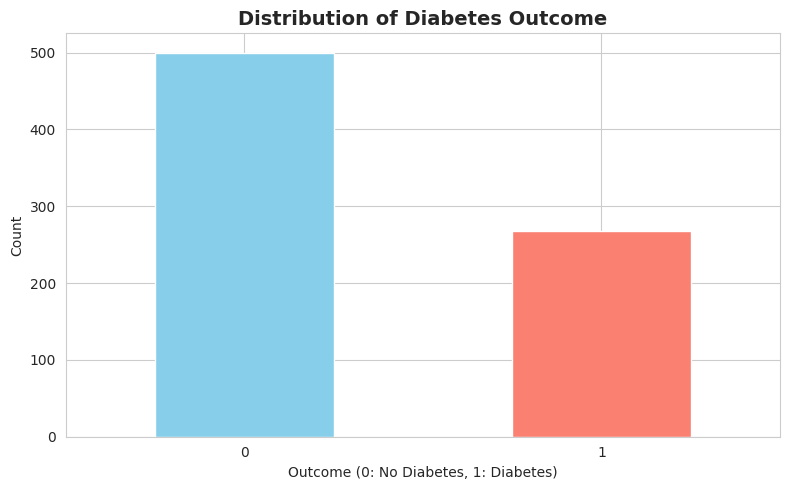

✓ Target variable distribution plotted

Creating histograms for all features...


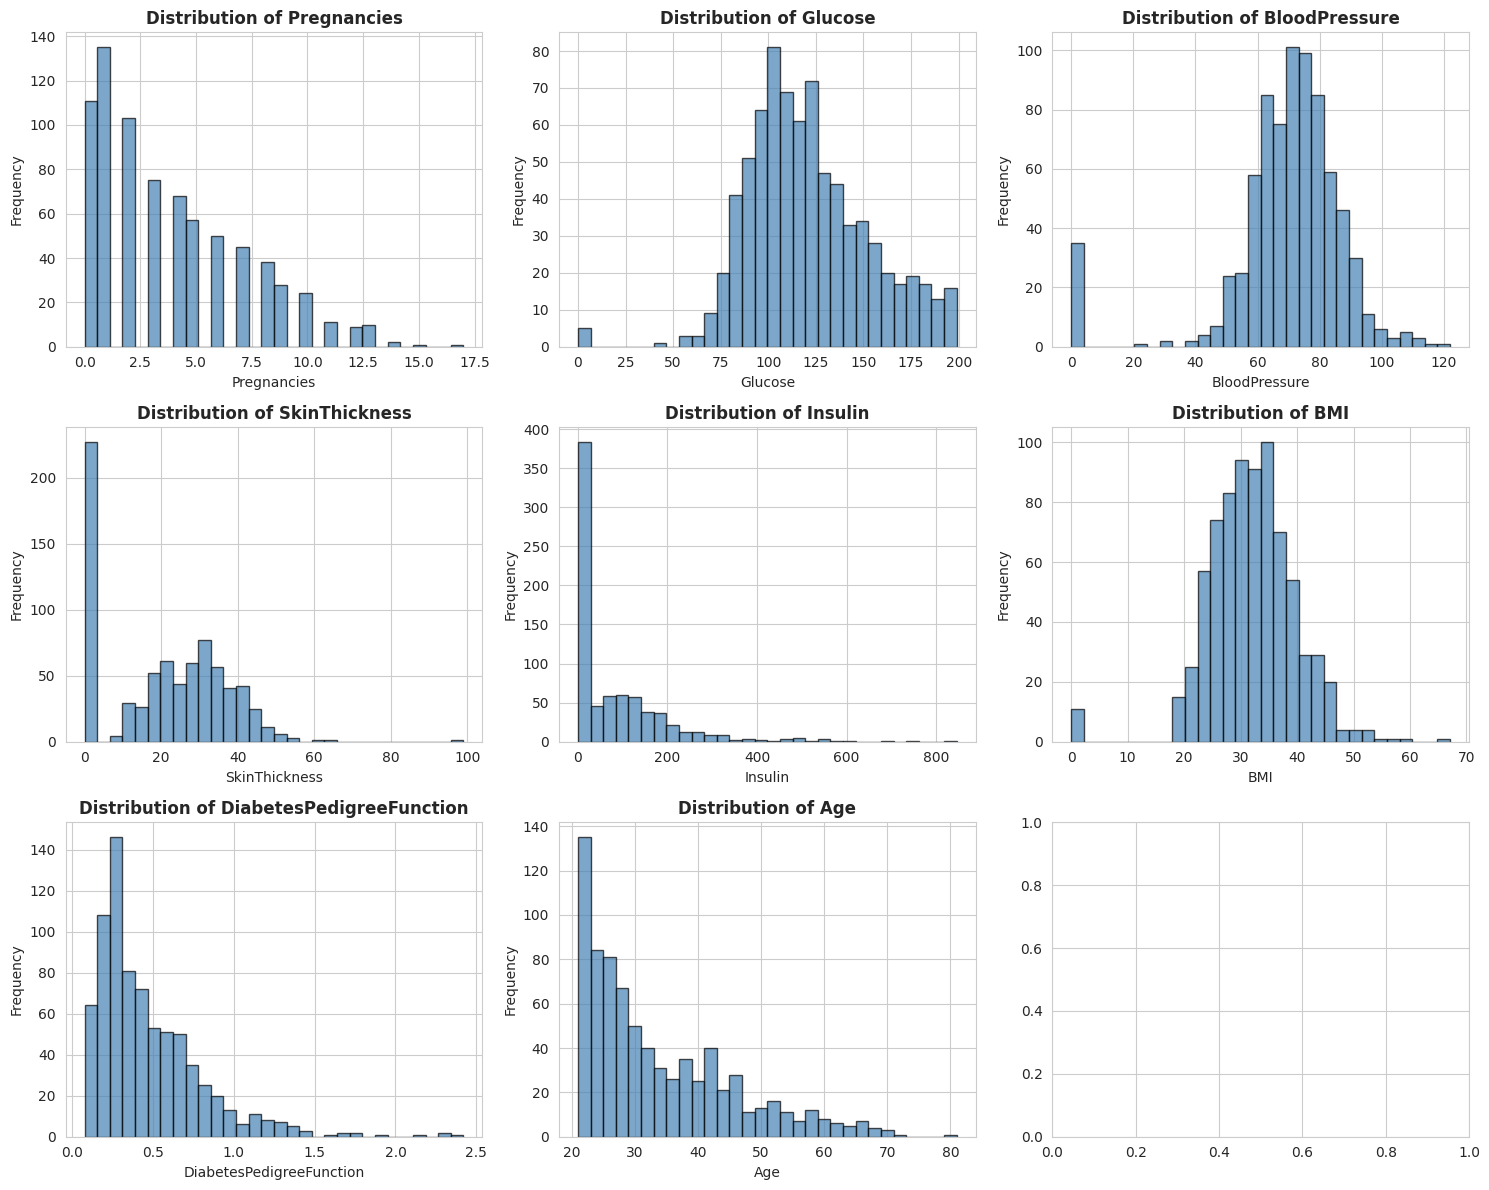

✓ Histograms plotted

Creating box plots to identify outliers...


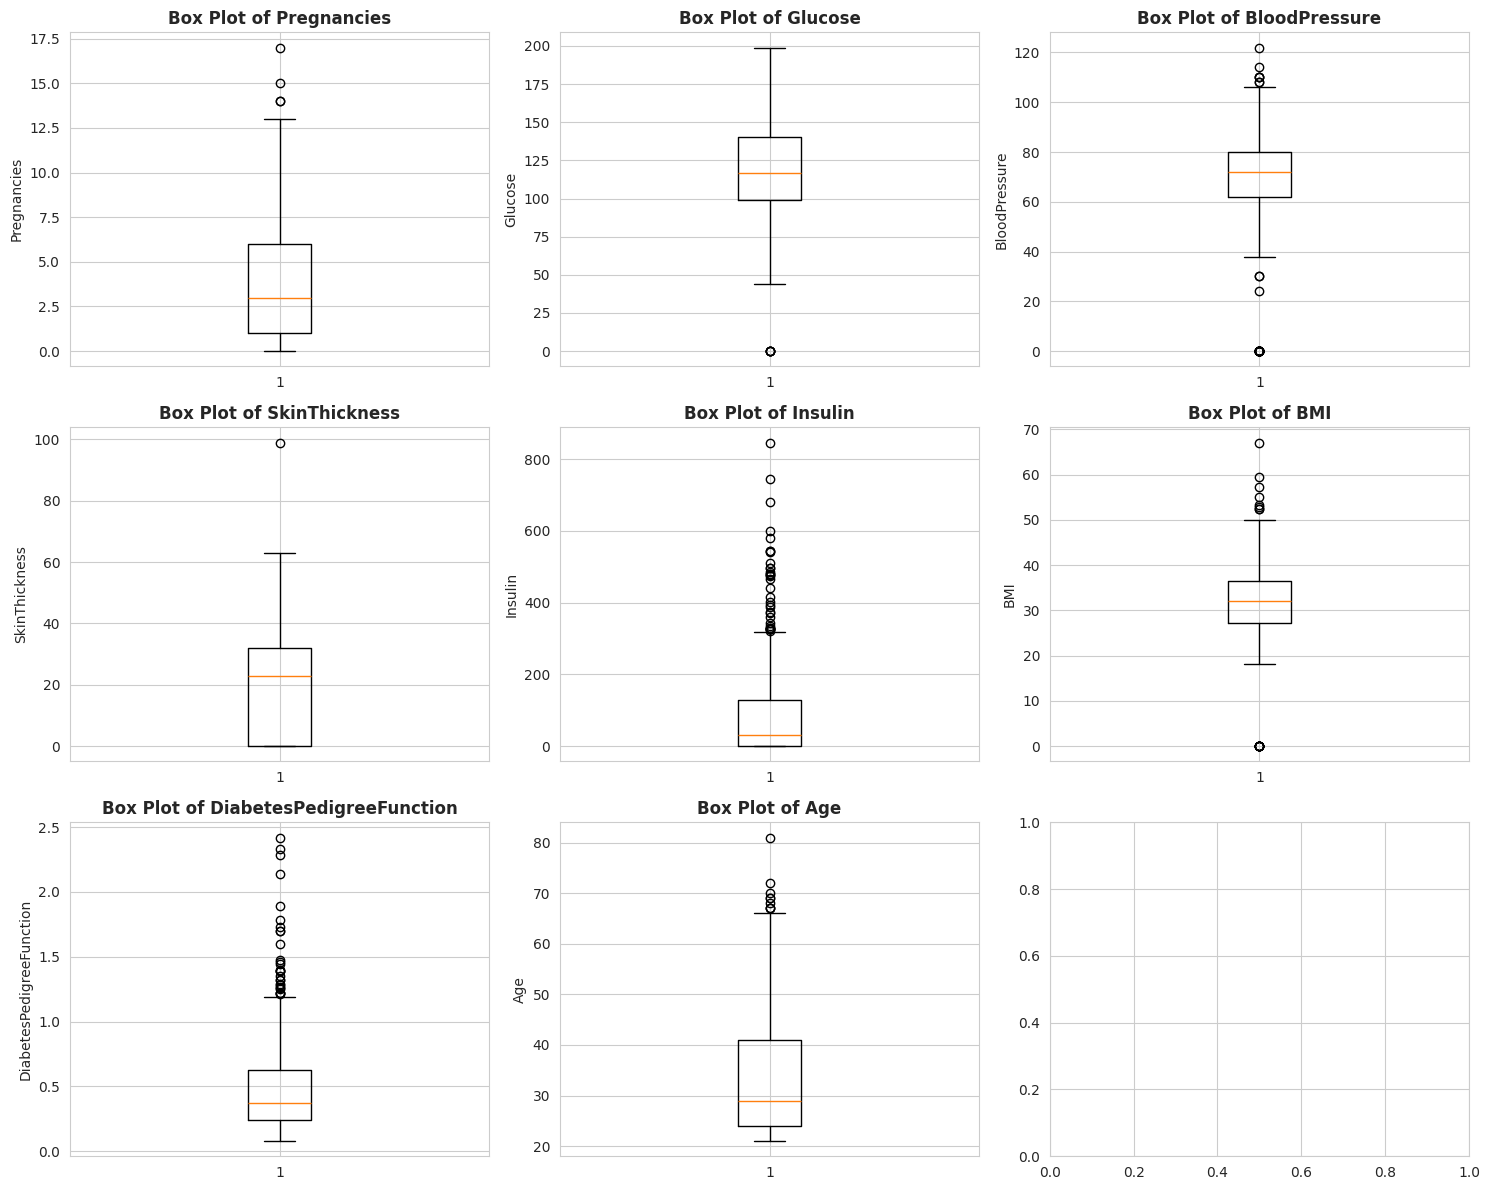

✓ Box plots plotted

Creating correlation heatmap...


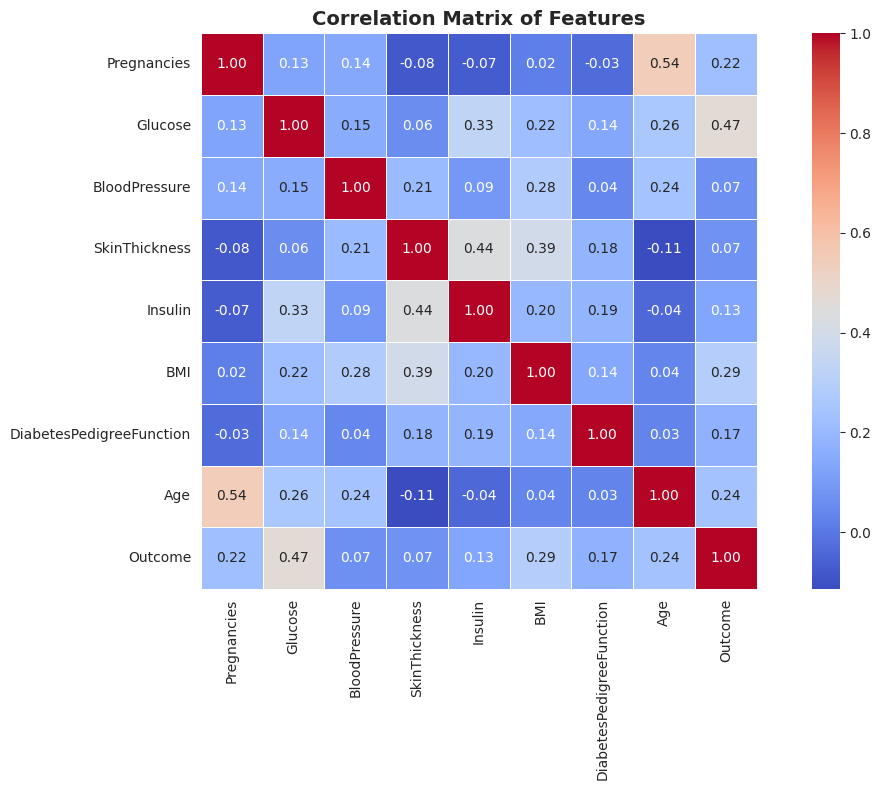

✓ Correlation heatmap plotted

Creating pair plot for key features...


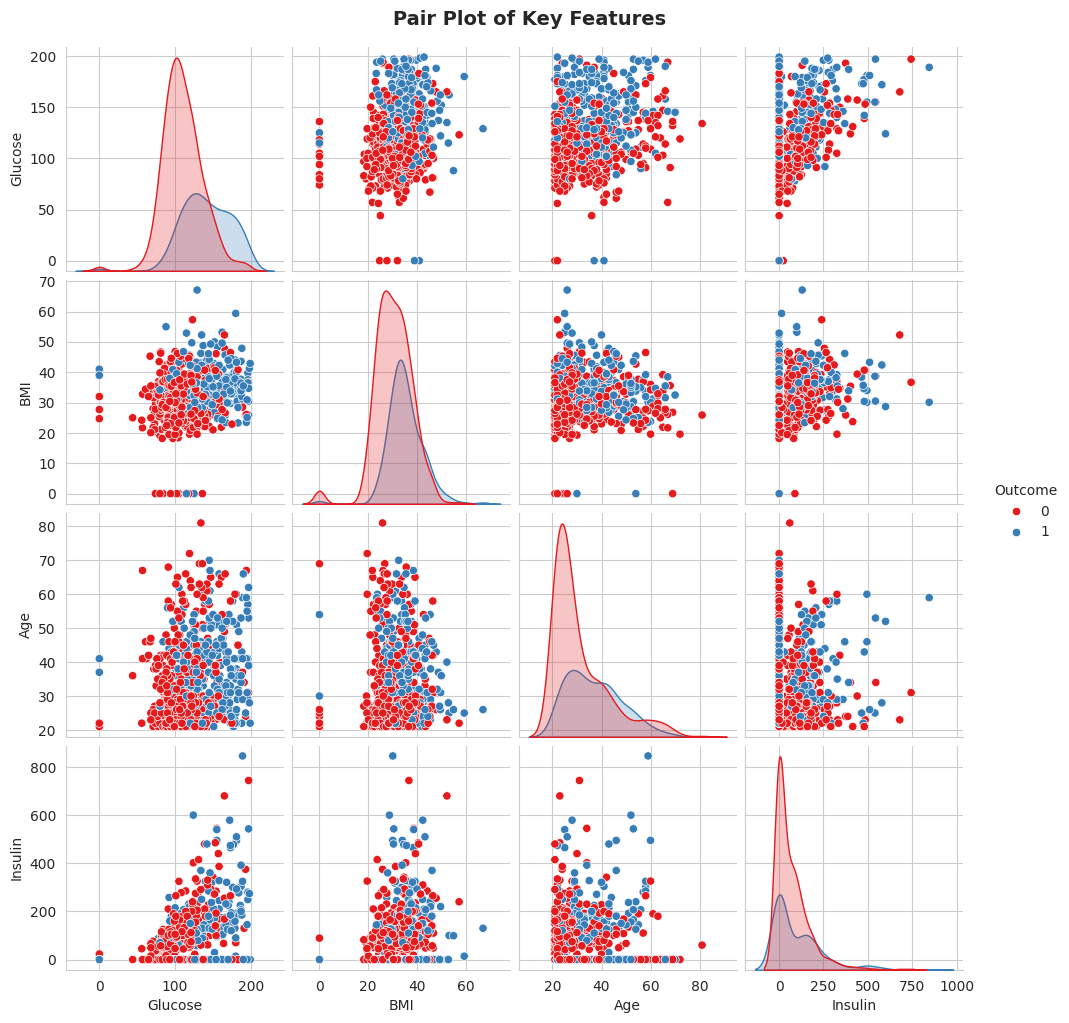

✓ Pair plot created

Creating distribution plots by outcome...


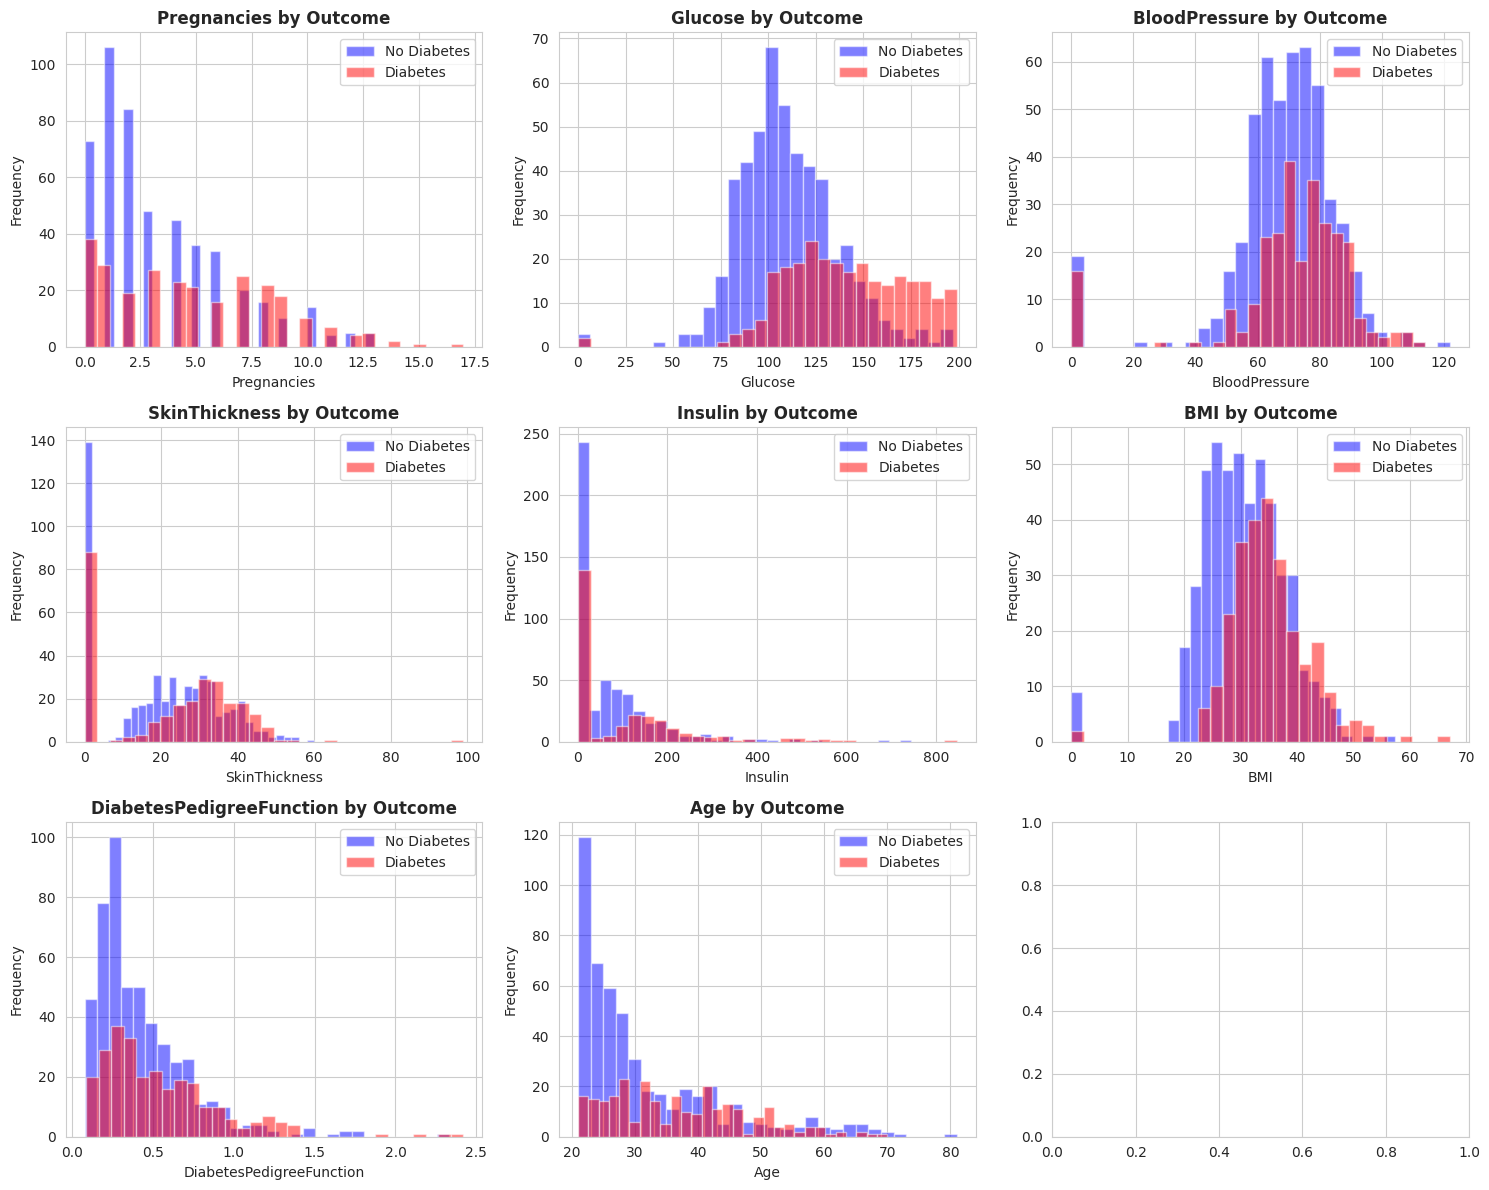

✓ Distribution plots by outcome created



In [10]:
# ========================================
# STEP 4: VISUALIZATIONS
# ========================================
print("=" * 50)
print("STEP 4: DATA VISUALIZATIONS")
print("=" * 50)

# 4.1 Target Variable Distribution
plt.figure(figsize=(8, 5))
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Diabetes Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print("✓ Target variable distribution plotted\n")

# 4.2 Distribution of Features (Histograms)
print("Creating histograms for all features...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = df.columns[:-1]  # All columns except Outcome

for idx, col in enumerate(features):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("✓ Histograms plotted\n")

# 4.3 Box Plots to Identify Outliers
print("Creating box plots to identify outliers...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, col in enumerate(features):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(df[col], vert=True)
    axes[row, col_idx].set_title(f'Box Plot of {col}', fontweight='bold')
    axes[row, col_idx].set_ylabel(col)

plt.tight_layout()
plt.show()
print("✓ Box plots plotted\n")

# 4.4 Correlation Heatmap
print("Creating correlation heatmap...")
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Correlation heatmap plotted\n")

# 4.5 Pair Plot (for selected features to avoid clutter)
print("Creating pair plot for key features...")
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df[key_features], hue='Outcome', palette='Set1', diag_kind='kde')
plt.suptitle('Pair Plot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()
print("✓ Pair plot created\n")

# 4.6 Feature Distributions by Outcome
print("Creating distribution plots by outcome...")
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for idx, col in enumerate(features):
    row = idx // 3
    col_idx = idx % 3

    df[df['Outcome'] == 0][col].hist(bins=30, alpha=0.5, label='No Diabetes',
                                      color='blue', ax=axes[row, col_idx])
    df[df['Outcome'] == 1][col].hist(bins=30, alpha=0.5, label='Diabetes',
                                      color='red', ax=axes[row, col_idx])

    axes[row, col_idx].set_title(f'{col} by Outcome', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].legend()

plt.tight_layout()
plt.show()
print("✓ Distribution plots by outcome created\n")


In [11]:
# ========================================
# STEP 5: DATA PREPROCESSING
# ========================================
print("=" * 50)
print("STEP 5: DATA PREPROCESSING")
print("=" * 50)

# 5.1 Handle Missing Values (Replace zeros with median)
print("\n--- Handling Missing Values ---")
print("Replacing zero values with median for specific columns...")

df_processed = df.copy()

# Replace zeros with NaN for columns where 0 is not valid
for col in zero_columns:
    df_processed[col] = df_processed[col].replace(0, np.nan)
    median_value = df_processed[col].median()
    df_processed[col].fillna(median_value, inplace=True)
    print(f"✓ {col}: Replaced zeros with median ({median_value:.2f})")

print("\nMissing values after preprocessing:")
print(df_processed.isnull().sum())
print("\n")

# 5.2 Feature Engineering (Optional - create age groups)
print("--- Feature Engineering ---")
df_processed['AgeGroup'] = pd.cut(df_processed['Age'],
                                   bins=[0, 30, 50, 100],
                                   labels=['Young', 'Middle', 'Senior'])
print("✓ Created AgeGroup feature")
print(df_processed['AgeGroup'].value_counts())
print("\n")

# 5.3 Separate Features and Target
print("--- Separating Features and Target ---")
X = df_processed.drop(['Outcome', 'AgeGroup'], axis=1)
y = df_processed['Outcome']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("\nFeatures:")
print(X.columns.tolist())
print("\n")

# 5.4 Train-Test Split
print("--- Splitting Data into Train and Test Sets ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTrain set - Diabetes distribution:")
print(y_train.value_counts())
print(f"\nTest set - Diabetes distribution:")
print(y_test.value_counts())
print("\n")

# 5.5 Feature Scaling
print("--- Feature Scaling (Standardization) ---")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")
print(f"Scaled training set shape: {X_train_scaled.shape}")
print(f"Scaled testing set shape: {X_test_scaled.shape}")
print("\n")


STEP 5: DATA PREPROCESSING

--- Handling Missing Values ---
Replacing zero values with median for specific columns...
✓ Glucose: Replaced zeros with median (117.00)
✓ BloodPressure: Replaced zeros with median (72.00)
✓ SkinThickness: Replaced zeros with median (29.00)
✓ Insulin: Replaced zeros with median (125.00)
✓ BMI: Replaced zeros with median (32.30)

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


--- Feature Engineering ---
✓ Created AgeGroup feature
AgeGroup
Young     417
Middle    270
Senior     81
Name: count, dtype: int64


--- Separating Features and Target ---
Features shape: (768, 8)
Target shape: (768,)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPe

In [12]:
# ========================================
# STEP 6: MODEL BUILDING
# ========================================
print("=" * 50)
print("STEP 6: MODEL BUILDING")
print("=" * 50)

# 6.1 Create and Train Logistic Regression Model
print("\n--- Training Logistic Regression Model ---")
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✓ Model training completed!")
print(f"Model parameters: {model.get_params()}")
print("\n")

# 6.2 Make Predictions
print("--- Making Predictions ---")
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_train_pred_proba = model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions generated for train and test sets\n")


STEP 6: MODEL BUILDING

--- Training Logistic Regression Model ---
✓ Model training completed!
Model parameters: {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


--- Making Predictions ---
✓ Predictions generated for train and test sets



STEP 7: MODEL EVALUATION

--- TRAINING SET PERFORMANCE ---
Accuracy:  0.7964
Precision: 0.7697
Recall:    0.5935
F1-Score:  0.6702
ROC-AUC:   0.8502

--- TESTING SET PERFORMANCE ---
Accuracy:  0.7078
Precision: 0.6000
Recall:    0.5000
F1-Score:  0.5455
ROC-AUC:   0.8130


--- DETAILED CLASSIFICATION REPORT (Test Set) ---
              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



--- CONFUSION MATRIX ---
[[82 18]
 [27 27]]




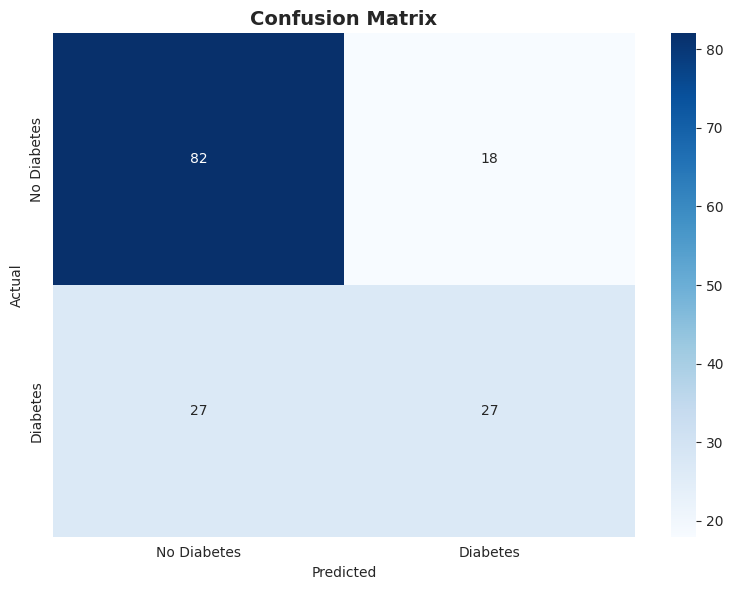

✓ Confusion matrix plotted

--- ROC CURVE ---


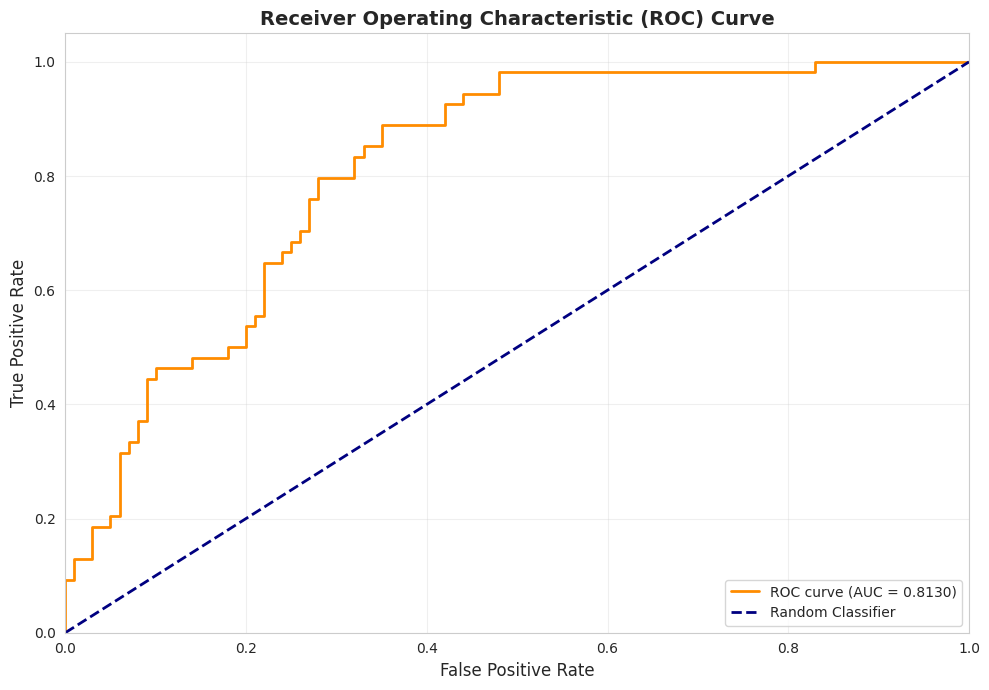

✓ ROC curve plotted

--- CROSS-VALIDATION (5-Fold) ---
Cross-validation scores: [0.7804878  0.7804878  0.76422764 0.7804878  0.80327869]
Mean CV Accuracy: 0.7818 (+/- 0.0249)




In [13]:
# ========================================
# STEP 7: MODEL EVALUATION
# ========================================
print("=" * 50)
print("STEP 7: MODEL EVALUATION")
print("=" * 50)

# 7.1 Training Set Performance
print("\n--- TRAINING SET PERFORMANCE ---")
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)

print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1-Score:  {train_f1:.4f}")
print(f"ROC-AUC:   {train_roc_auc:.4f}")

# 7.2 Testing Set Performance
print("\n--- TESTING SET PERFORMANCE ---")
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("\n")

# 7.3 Classification Report
print("--- DETAILED CLASSIFICATION REPORT (Test Set) ---")
print(classification_report(y_test, y_test_pred,
                          target_names=['No Diabetes', 'Diabetes']))
print("\n")

# 7.4 Confusion Matrix
print("--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print("\n")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print("✓ Confusion matrix plotted\n")

# 7.5 ROC Curve
print("--- ROC CURVE ---")
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ ROC curve plotted\n")

# 7.6 Cross-Validation
print("--- CROSS-VALIDATION (5-Fold) ---")
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print("\n")

STEP 8: MODEL INTERPRETATION

--- LOGISTIC REGRESSION COEFFICIENTS ---
                    Feature  Coefficient  Abs_Coefficient
1                   Glucose     1.182511         1.182511
5                       BMI     0.688735         0.688735
0               Pregnancies     0.377502         0.377502
6  DiabetesPedigreeFunction     0.233386         0.233386
7                       Age     0.147798         0.147798
4                   Insulin    -0.066157         0.066157
2             BloodPressure    -0.044066         0.044066
3             SkinThickness     0.028225         0.028225




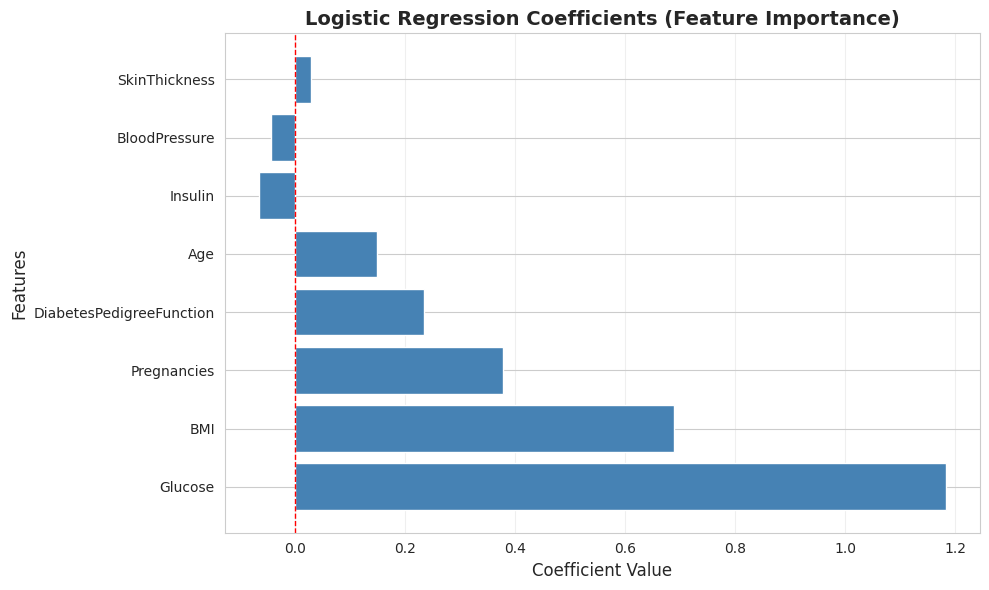

✓ Feature importance plotted

--- INTERPRETATION ---

Positive coefficients increase the probability of diabetes:
                    Feature  Coefficient
1                   Glucose     1.182511
5                       BMI     0.688735
0               Pregnancies     0.377502
6  DiabetesPedigreeFunction     0.233386
7                       Age     0.147798
3             SkinThickness     0.028225

Negative coefficients decrease the probability of diabetes:
         Feature  Coefficient
4        Insulin    -0.066157
2  BloodPressure    -0.044066


Model Intercept: -0.8722




In [14]:
# ========================================
# STEP 8: MODEL INTERPRETATION
# ========================================
print("=" * 50)
print("STEP 8: MODEL INTERPRETATION")
print("=" * 50)

# 8.1 Feature Coefficients
print("\n--- LOGISTIC REGRESSION COEFFICIENTS ---")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coefficient': np.abs(model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print(coefficients)
print("\n")

# 8.2 Visualize Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Logistic Regression Coefficients (Feature Importance)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ Feature importance plotted\n")

# 8.3 Interpretation
print("--- INTERPRETATION ---")
print("\nPositive coefficients increase the probability of diabetes:")
print(coefficients[coefficients['Coefficient'] > 0][['Feature', 'Coefficient']])

print("\nNegative coefficients decrease the probability of diabetes:")
print(coefficients[coefficients['Coefficient'] < 0][['Feature', 'Coefficient']])
print("\n")

# 8.4 Intercept
print(f"Model Intercept: {model.intercept_[0]:.4f}")
print("\n")

In [15]:
# ========================================
# STEP 9: PREDICTION EXAMPLE
# ========================================
print("=" * 50)
print("STEP 9: EXAMPLE PREDICTION")
print("=" * 50)

# Create a sample patient
sample_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
sample_patient_scaled = scaler.transform(sample_patient)

prediction = model.predict(sample_patient_scaled)
prediction_proba = model.predict_proba(sample_patient_scaled)

print("\nSample Patient Data:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {sample_patient[0][i]}")

print(f"\nPrediction: {'Diabetes' if prediction[0] == 1 else 'No Diabetes'}")
print(f"Probability of No Diabetes: {prediction_proba[0][0]:.4f}")
print(f"Probability of Diabetes: {prediction_proba[0][1]:.4f}")
print("\n")


STEP 9: EXAMPLE PREDICTION

Sample Patient Data:
  Pregnancies: 6.0
  Glucose: 148.0
  BloodPressure: 72.0
  SkinThickness: 35.0
  Insulin: 0.0
  BMI: 33.6
  DiabetesPedigreeFunction: 0.627
  Age: 50.0

Prediction: Diabetes
Probability of No Diabetes: 0.2728
Probability of Diabetes: 0.7272




In [16]:
# ========================================
# STEP 10: SAVE THE MODEL (Optional)
# ========================================
print("=" * 50)
print("STEP 10: SAVING THE MODEL")
print("=" * 50)

import pickle

# Save the model
with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✓ Model saved as 'diabetes_model.pkl'")
print("✓ Scaler saved as 'scaler.pkl'")
print("\n")

# ========================================
# SUMMARY
# ========================================
print("=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"""
Model Performance Summary:
--------------------------
Test Accuracy:  {test_accuracy:.4f}
Test Precision: {test_precision:.4f}
Test Recall:    {test_recall:.4f}
Test F1-Score:  {test_f1:.4f}
Test ROC-AUC:   {test_roc_auc:.4f}

Top 3 Most Important Features:
{coefficients.head(3)[['Feature', 'Coefficient']].to_string(index=False)}

Model is ready for deployment!
""")

print("=" * 50)
print("WORKFLOW COMPLETED SUCCESSFULLY!")
print("=" * 50)

STEP 10: SAVING THE MODEL
✓ Model saved as 'diabetes_model.pkl'
✓ Scaler saved as 'scaler.pkl'


SUMMARY

Model Performance Summary:
--------------------------
Test Accuracy:  0.7078
Test Precision: 0.6000
Test Recall:    0.5000
Test F1-Score:  0.5455
Test ROC-AUC:   0.8130

Top 3 Most Important Features:
    Feature  Coefficient
    Glucose     1.182511
        BMI     0.688735
Pregnancies     0.377502

Model is ready for deployment!

WORKFLOW COMPLETED SUCCESSFULLY!
